# Advances in Complex Systems: Inequality, 29 June – 3 July, 2026
## Italian Socio-Economic & Geospatial Data

**Exploratory analysis + geographic analysis (income & real-estate prices).**

This notebook documents, loads, and explores a collection of Italian open data focused on
**Lombardy / Milan / Como**, then performs a geographic analysis joining income and real-estate
prices onto administrative boundaries with **GeoPandas**.

The analysis can run for all of Italy or zoom to a region / province (see the *Parameters* cell)

To run this notebook it is require to install the packages described in the file **requirements.txt**
See SETUP.md

## 1. What is in the dataset

The data lives under `data/`. It combines administrative geometry, postal-code zones, real-estate
market values, and personal-income tax statistics — all linkable by Italian municipality.

| Layer | Path | Type / CRS | Key fields |
|---|---|---|---|
| Municipal boundaries (ISTAT 2020, **Lombardy only**, ~1,506 comuni) | `data/limiti_comunali_2020.geojson` | GeoJSON polygons | `belfiore`, `istat`, `nome_com`, `nome_reg`, `sig_pro` |
| Census sections (Lombardy) | `data/census_lom.gpkg` | GeoPackage polygons | — |
| Eurostat LAU 2021 (EU) | `data/ref-lau-2021-01m.shp/` | Shapefile, EPSG:3035 | `GISCO_ID`, `LAU_NAME`, `POP_2021`, `AREA_KM2` |
| CAP zones (national) | `data/atlante_istat/CodAvvPostale/` | Shapefile, ED50/UTM32N | `CAP` |
| CAP zones (Milan, with usage) | `data/banchedati-cap-zone-demo-database/CAPZONE_Milano.shp` | Shapefile, WGS84 | `CAP`, `COMUNE`, `ABITAZIONI`, `NEGOZI`, `UFFICI` |
| CAP points (Lombardy 2020) | `data/pointcaps_lom2020/` | Shapefile, ETRS89 | `POSTCODE`, `GISCO_ID`, `FUA_ID` |
| OMI real-estate quotations (**Lombardy**) | `data/omi/{2011,2021}/quotazioni.csv` | CSV (`;`) | `Comune_amm`, `Zona`, `Compr_min/max`, `Loc_min/max` |
| OMI zone polygons | `data/omi/{2011,2021}/zone/*.kml` | KML (~7.4k–7.9k zones) | — |
| Income (IRPEF, MEF) — municipal | `data/Redditi/{year}/comunali.csv` | CSV (`;`) | `Codice catastale`, `Codice Istat Comune`, `Reddito imponibile - *` |
| Income — sub-municipal (by CAP) | `data/Redditi/{year}/subcomunali.csv` | CSV (`;`) | `CAP`, `Codice Istat Comune`, income columns |

> **Coverage asymmetry (read before mapping):** the *income* tables are **national** (all 22 regions,
> ~7,900 comuni), but the only municipal **geometry** here — `limiti_comunali_2020.geojson` — plus the
> OMI prices and the census layer cover **Lombardy only**. So the *income EDA* can target any region
> via the `REGION` parameter, while **maps are inherently Lombardy** (zoom within it with
> `FOCUS_PROVINCE`, e.g. Como `CO` or Milan `MI`). National mapping would require the EU LAU layer.

**Sources:** ISTAT (boundaries, CAP), Eurostat GISCO (LAU), Agenzia delle Entrate — *OMI*
(real-estate quotations), MEF — Dipartimento delle Finanze (*Redditi* IRPEF declarations).

**The unifying join key is the *Belfiore* cadastral code** (e.g. `A001`), which appears as:
`Codice catastale` (Redditi) ↔ `Comune_amm` (OMI) ↔ `belfiore` (boundaries). We use it to merge the
three sources at municipality level.

**Format notes:** CSVs are `;`-separated with Italian column names; OMI rent values use a decimal
comma (`12,8`); files carry a trailing empty column. CRS differ across layers, so we reproject to a
common CRS before any spatial operation.


## 2. Parameters

Change these to retarget the whole notebook.

In [1]:
from pathlib import Path

DATA_DIR = Path("data")

YEAR      = 2022          # Redditi (income) year: 2011, 2015, 2019, 2020, 2021, 2022
OMI_YEAR  = 2021          # OMI real-estate year: 2011 or 2021

# Geographic scope.
#  - REGION drives the (national) income EDA: "LOMBARDIA", "LAZIO", ... or None for all Italy.
#  - Maps use the boundary geometry, which covers LOMBARDIA only, so spatial sections always
#    render Lombardy; use FOCUS_PROVINCE to zoom inside it.
REGION          = "LOMBARDIA"   # income-EDA scope
FOCUS_PROVINCE  = "CO"          # map zoom within Lombardy: "CO" (Como), "MI" (Milano), ... or None

COMMON_CRS = 3857         # Web Mercator, lets us add contextily basemaps
ADD_BASEMAP = True        # set False to skip basemap tiles (e.g. offline)

print(f"Income year={YEAR}  OMI year={OMI_YEAR}  region={REGION}  focus={FOCUS_PROVINCE}")

Income year=2022  OMI year=2021  region=LOMBARDIA  focus=CO


## 3. Imports & helpers

In [3]:
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

try:
    import contextily as cx
    HAS_CTX = True
except Exception:
    HAS_CTX = False
    ADD_BASEMAP = False

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)


def read_istat_csv(path, **kwargs):
    # Read a ;-separated Italian-locale CSV (decimals as comma); try utf-8 then latin1,
    # and drop the trailing empty column these files carry.
    for enc in ("utf-8", "latin1"):
        try:
            df = pd.read_csv(path, sep=";", decimal=",", encoding=enc,
                             low_memory=False, **kwargs)
            break
        except UnicodeDecodeError:
            continue
    # drop trailing unnamed/empty column(s)
    df = df.loc[:, ~df.columns.str.match(r"^Unnamed|^\s*$")]
    df.columns = df.columns.str.strip()
    return df


def belfiore(series):
    # Normalize a Belfiore cadastral code column for joining.
    return series.astype(str).str.strip().str.upper()

## 4. Load tabular data (income & real-estate)

In [5]:
# --- Income (Redditi) at municipal level ---
red_path = DATA_DIR / "Redditi" / str(YEAR) / "comunali.csv"
redditi = read_istat_csv(red_path)
print("Redditi comunali:", redditi.shape)
redditi.head(3)

Redditi comunali: (7901, 50)


,Anno di imposta,Codice catastale,Codice Istat Comune,Denominazione Comune,Sigla Provincia,Regione,Codice Istat Regione,Numero contribuenti,Reddito da fabbricati - Frequenza,Reddito da fabbricati - Ammontare in euro,Reddito da lavoro dipendente e assimilati - Frequenza,Reddito da lavoro dipendente e assimilati - Ammontare in euro,Reddito da pensione - Frequenza,Reddito da pensione - Ammontare in euro,Reddito da lavoro autonomo (comprensivo dei valori nulli) - Frequenza,Reddito da lavoro autonomo (comprensivo dei valori nulli) - Ammontare in euro,Reddito di spettanza dell'imprenditore in contabilita' ordinaria (comprensivo dei valori nulli) - Frequenza,Reddito di spettanza dell'imprenditore in contabilita' ordinaria (comprensivo dei valori nulli) - Ammontare in euro,Reddito di spettanza dell'imprenditore in contabilita' semplificata (comprensivo dei valori nulli) - Frequenza,Reddito di spettanza dell'imprenditore in contabilita' semplificata (comprensivo dei valori nulli) - Ammontare in euro,Reddito da partecipazione (comprensivo dei valori nulli) - Frequenza,Reddito da partecipazione (comprensivo dei valori nulli) - Ammontare in euro,Reddito imponibile - Frequenza,Reddito imponibile - Ammontare in euro,Imposta netta - Frequenza,Imposta netta - Ammontare in euro,Trattamento spettante - Frequenza,Trattamento spettante - Ammontare in euro,Reddito imponibile addizionale - Frequenza,Reddito imponibile addizionale - Ammontare in euro,Addizionale regionale dovuta - Frequenza,Addizionale regionale dovuta - Ammontare in euro,Addizionale comunale dovuta - Frequenza,Addizionale comunale dovuta - Ammontare in euro,Reddito complessivo minore o uguale a zero euro - Frequenza,Reddito complessivo minore o uguale a zero euro - Ammontare in euro,Reddito complessivo da 0 a 10000 euro - Frequenza,Reddito complessivo da 0 a 10000 euro - Ammontare in euro,Reddito complessivo da 10000 a 15000 euro - Frequenza,Reddito complessivo da 10000 a 15000 euro - Ammontare in euro,Reddito complessivo da 15000 a 26000 euro - Frequenza,Reddito complessivo da 15000 a 26000 euro - Ammontare in euro,Reddito complessivo da 26000 a 55000 euro - Frequenza,Reddito complessivo da 26000 a 55000 euro - Ammontare in euro,Reddito complessivo da 55000 a 75000 euro - Frequenza,Reddito complessivo da 55000 a 75000 euro - Ammontare in euro,Reddito complessivo da 75000 a 120000 euro - Frequenza,Reddito complessivo da 75000 a 120000 euro - Ammontare in euro,Reddito complessivo oltre 120000 euro - Frequenza,Reddito complessivo oltre 120000 euro - Ammontare in euro
0,2022,A001,28001,ABANO TERME,PD,Veneto,5,15456,7922,9984985,8316,202328396,5546,122795358,260.0,19209139.0,63.0,5829042.0,435.0,12800053.0,934.0,21398025.0,14703,385196262,12467,79717946,1688.0,1403312.0,12277,369836147,12161,4543249,10668.0,2813223.0,5.0,-68834.0,3269,14956682,1669.0,20970333.0,4986,102911906,3988.0,140075324.0,506.0,32294680.0,433.0,40181799.0,283.0,60130169.0
1,2022,A004,98001,ABBADIA CERRETO,LO,Lombardia,3,209,96,72905,104,2235848,80,1491197,0.0,0.0,0.0,0.0,5.0,101990.0,15.0,136433.0,188,3894764,160,610000,24.0,20720.0,160,3675247,159,50555,146.0,21398.0,0.0,0.0,41,206729,30.0,375367.0,74,1529371,49.0,1610308.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2022,A005,97001,ABBADIA LARIANA,LC,Lombardia,3,2515,1213,1897625,1386,35375399,879,19269259,31.0,1585584.0,NaN,NaN,62.0,1722207.0,98.0,2606648.0,2411,60787634,2056,11570225,234.0,206989.0,2009,57896106,1997,834348,1656.0,406338.0,0.0,0.0,455,2051953,232.0,2897366.0,810,16860767,760.0,26366423.0,92.0,5838342.0,62.0,5716027.0,34.0,5986831.0


In [4]:
# Column names are long; map the few we need to short handles.
COL_TAXPAYERS = "Numero contribuenti"
COL_INCOME    = "Reddito imponibile - Ammontare in euro"
COL_ISTAT     = "Codice Istat Comune"
COL_CAT       = "Codice catastale"
COL_PROV      = "Sigla Provincia"
COL_REGION    = "Regione"
COL_COMUNE    = "Denominazione Comune"

# Average taxable income per taxpayer (euro) — our headline income indicator.
redditi["avg_income"] = redditi[COL_INCOME] / redditi[COL_TAXPAYERS]
redditi["belfiore"]   = belfiore(redditi[COL_CAT])

# Optional region filter (income table uses full region names in `Regione`).
if REGION is not None:
    red_view = redditi[redditi[COL_REGION].str.upper() == REGION.upper()].copy()
else:
    red_view = redditi.copy()
print(f"Municipalities in scope: {len(red_view)} (of {len(redditi)} national)")
red_view[[COL_COMUNE, COL_PROV, COL_REGION, COL_TAXPAYERS, "avg_income"]].head()

Municipalities in scope: 1503 (of 7901 national)


,Denominazione Comune,Sigla Provincia,Regione,Numero contribuenti,avg_income
1,ABBADIA CERRETO,LO,Lombardia,209,18635.234450
2,ABBADIA LARIANA,LC,Lombardia,2515,24170.033400
6,ABBIATEGRASSO,MI,Lombardia,23619,24487.834667
25,ACQUAFREDDA,BS,Lombardia,1095,20363.714155
27,ACQUANEGRA SUL CHIESE,MN,Lombardia,2115,19007.086052


In [5]:
# --- Real-estate (OMI) quotations ---
omi_path = DATA_DIR / "omi" / str(OMI_YEAR) / "quotazioni.csv"
omi = read_istat_csv(omi_path)
print("OMI quotazioni:", omi.shape)
omi[["Regione", "Prov", "Comune_descrizione", "Zona", "Descr_Tipologia",
     "Compr_min", "Compr_max", "Loc_min", "Loc_max"]].head(3)

OMI quotazioni: (26096, 21)


,Regione,Prov,Comune_descrizione,Zona,Descr_Tipologia,Compr_min,Compr_max,Loc_min,Loc_max
0,LOMBARDIA,BG,BERGAMO,B1,Abitazioni civili,2800.0,3200.0,10.0,12.8
1,LOMBARDIA,BG,BERGAMO,B1,Abitazioni civili,2100.0,3000.0,8.8,11.7
2,LOMBARDIA,BG,BERGAMO,B1,Abitazioni di tipo economico,1700.0,2300.0,5.4,8.0


## 5. Exploratory analysis — income (non-spatial)

Distribution and ranking of **average taxable income per taxpayer** across municipalities in scope.

count     1503.0
mean     22181.0
std       3361.0
min       6766.0
25%      20390.0
50%      22206.0
75%      23956.0
max      49524.0
Name: avg_income, dtype: float64


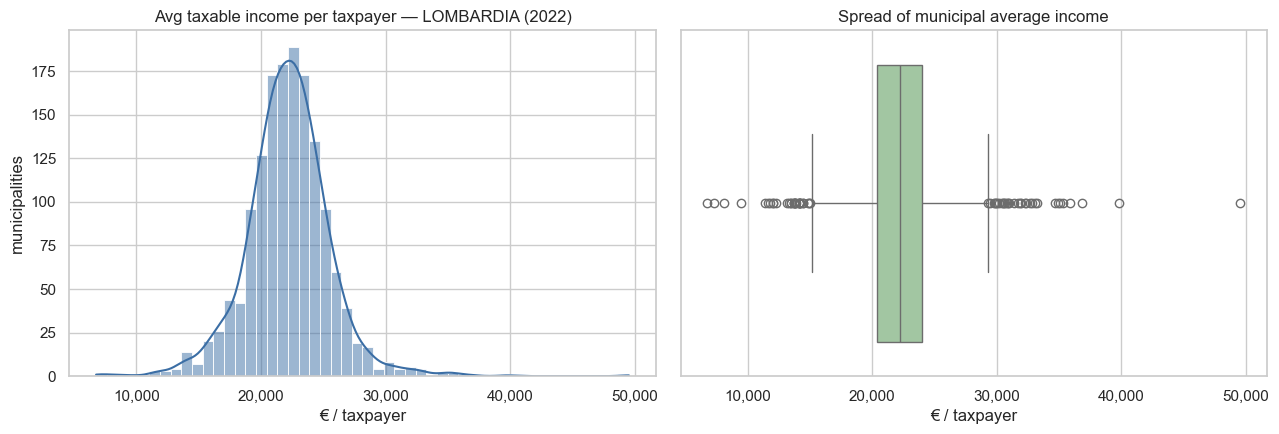

In [6]:
desc = red_view["avg_income"].describe()
print(desc.round(0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(red_view["avg_income"], bins=50, kde=True, ax=axes[0], color="#3b6ea5")
axes[0].set(title=f"Avg taxable income per taxpayer — {REGION or 'Italy'} ({YEAR})",
            xlabel="€ / taxpayer", ylabel="municipalities")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

sns.boxplot(x=red_view["avg_income"], ax=axes[1], color="#9ccc9c")
axes[1].set(title="Spread of municipal average income", xlabel="€ / taxpayer")
axes[1].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

In [7]:
# Top & bottom municipalities by average income (within scope).
cols = [COL_COMUNE, COL_PROV, COL_TAXPAYERS, "avg_income"]
top = red_view.nlargest(10, "avg_income")[cols]
bot = red_view[red_view[COL_TAXPAYERS] > 500].nsmallest(10, "avg_income")[cols]
print("Top 10 by avg income:"); display(top.round(0))
print("\nBottom 10 (municipalities with >500 taxpayers):"); display(bot.round(0))

Top 10 by avg income:


,Denominazione Comune,Sigla Provincia,Numero contribuenti,avg_income
557,BASIGLIO,MI,5704,49524.0
2457,CUSAGO,MI,3435,39814.0
7040,TORRE D'ISOLA,PV,1852,36841.0
6516,SEGRATE,MI,27611,35866.0
3950,MILANO,MI,1034105,35282.0
4740,PADENGHE SUL GARDA,BS,3561,35041.0
316,ARESE,MI,14713,34879.0
2939,GALLIATE LOMBARDO,VA,750,34640.0
5962,SAN DONATO MILANESE,MI,24162,33213.0
7362,VEDANO AL LAMBRO,MB,5781,33061.0



Bottom 10 (municipalities with >500 taxpayers):


,Denominazione Comune,Sigla Provincia,Numero contribuenti,avg_income
2250,VALSOLDA,CO,901,11653.0
7505,VILLA DI CHIAVENNA,SO,669,12040.0
3423,LAVENA PONTE TRESA,VA,3146,12042.0
1014,CADEGLIANO-VICONAGO,VA,1165,13346.0
1368,CARLAZZO,CO,1793,13447.0
2153,CLIVIO,VA,1147,13690.0
2434,CUGLIATE-FABIASCO,VA,1551,13726.0
5271,PORLEZZA,CO,3049,13769.0
2563,DUMENZA,VA,841,14224.0
5875,SALTRIO,VA,1608,14452.0


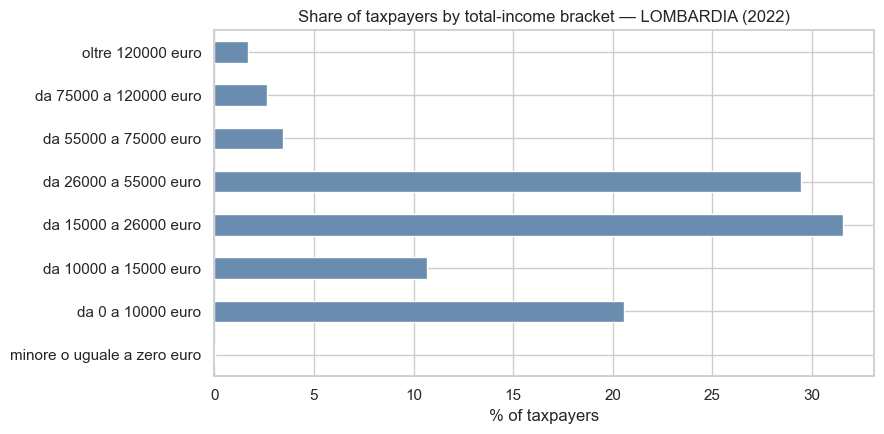

In [8]:
# Income-bracket composition (share of taxpayers per bracket) — frequency columns.
bracket_cols = [c for c in red_view.columns
                if c.startswith("Reddito complessivo") and c.endswith("Frequenza")]
short = (pd.Series(bracket_cols)
         .str.replace("Reddito complessivo ", "", regex=False)
         .str.replace(" - Frequenza", "", regex=False))
shares = red_view[bracket_cols].sum()
shares.index = short
shares = (shares / shares.sum() * 100)

ax = shares.plot(kind="barh", figsize=(9, 4.5), color="#6a8caf")
ax.set(title=f"Share of taxpayers by total-income bracket — {REGION or 'Italy'} ({YEAR})",
       xlabel="% of taxpayers"); plt.tight_layout(); plt.show()

## 6. Load & inspect administrative geometry

Read the national municipal boundaries, filter to the region early (the file is ~49 MB), and
reproject to the common CRS.

In [9]:
gdf_all = gpd.read_file(DATA_DIR / "limiti_comunali_2020.geojson")
print("Municipal polygons (national):", gdf_all.shape, "| CRS:", gdf_all.crs)
gdf_all[["nome_com", "nome_reg", "sig_pro", "belfiore", "istat"]].head(3)

Municipal polygons (national): (1506, 23) | CRS: EPSG:4326


,nome_com,nome_reg,sig_pro,belfiore,istat
0,PESCAROLO ED UNITI,LOMBARDIA,CR,G483,19069
1,INZAGO,LOMBARDIA,MI,E317,15114
2,FLERO,LOMBARDIA,BS,D634,17072


Polygons in scope: 1506


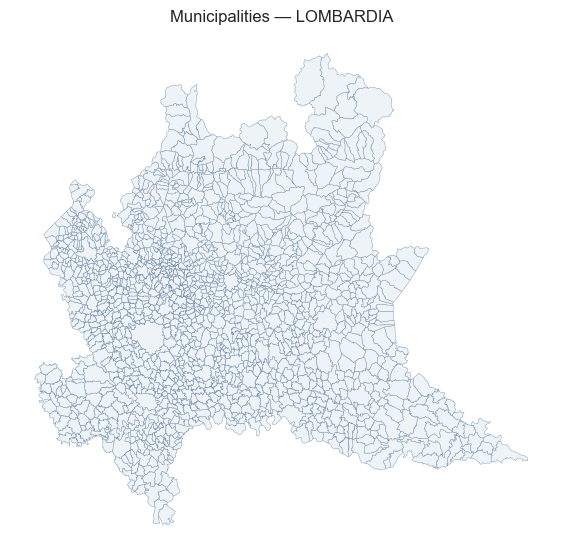

In [10]:
# The boundary file covers Lombardy only. Filter to REGION if it's present, else use all
# available geometry (so maps still render when REGION points elsewhere).
avail = set(gdf_all["nome_reg"].str.upper().dropna())
if REGION is not None and REGION.upper() in avail:
    muni = gdf_all[gdf_all["nome_reg"].str.upper() == REGION.upper()]
else:
    if REGION is not None:
        print(f"NOTE: '{REGION}' not in boundary file (covers {sorted(avail)}); mapping all available geometry.")
    muni = gdf_all
muni = muni.to_crs(epsg=COMMON_CRS).copy()
muni["belfiore"] = belfiore(muni["belfiore"])
print(f"Polygons in scope: {len(muni)}")

ax = muni.plot(figsize=(7, 7), facecolor="#eef3f8", edgecolor="#7a93ad", linewidth=0.3)
ax.set_axis_off(); ax.set_title(f"Municipalities — {REGION or 'Italy'}"); plt.show()

## 7. Spatial join — income onto municipalities

Merge income onto the polygons by the **Belfiore** code and render a choropleth of average income.

In [11]:
muni_inc = muni.merge(
    red_view[["belfiore", COL_COMUNE, COL_PROV, COL_TAXPAYERS, "avg_income", COL_INCOME]],
    on="belfiore", how="left")

matched = muni_inc["avg_income"].notna().mean() * 100
print(f"Income join coverage: {matched:.1f}% of polygons matched")

Income join coverage: 99.7% of polygons matched


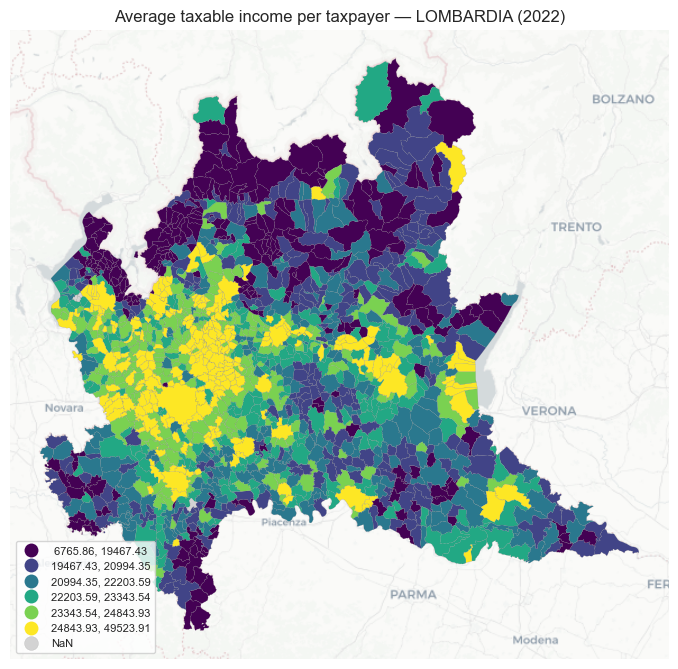

In [12]:
def choropleth(gdf, column, title, cmap="viridis", ax=None, scheme="quantiles", k=6):
    if ax is None:
        _, ax = plt.subplots(figsize=(8.5, 8.5))
    gdf.plot(column=column, cmap=cmap, scheme=scheme, k=k, legend=True,
             linewidth=0.1, edgecolor="grey", missing_kwds={"color": "lightgrey"},
             legend_kwds={"loc": "lower left", "fontsize": 8}, ax=ax)
    if ADD_BASEMAP and HAS_CTX:
        try:
            cx.add_basemap(ax, crs=gdf.crs, source=cx.providers.CartoDB.Positron, attribution=False)
        except Exception as e:
            print("basemap skipped:", e)
    ax.set_axis_off(); ax.set_title(title, fontsize=12)
    return ax

choropleth(muni_inc, "avg_income",
           f"Average taxable income per taxpayer — {REGION or 'Italy'} ({YEAR})",
           cmap="viridis")
plt.show()

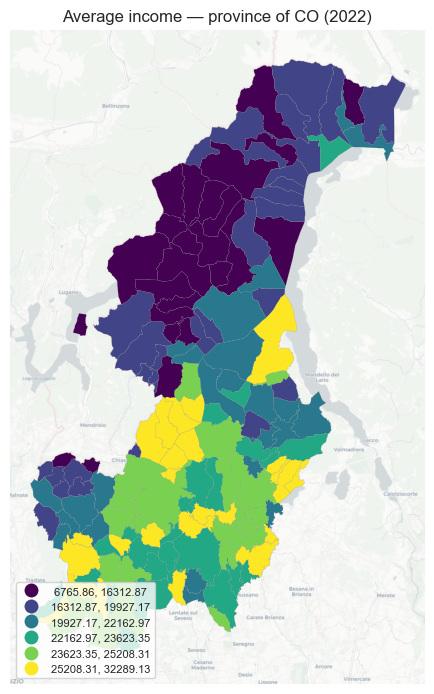

In [13]:
# Province zoom (e.g. Como) for detail.
if FOCUS_PROVINCE:
    focus = muni_inc[muni_inc[COL_PROV] == FOCUS_PROVINCE]
    if len(focus):
        ax = choropleth(focus, "avg_income",
                        f"Average income — province of {FOCUS_PROVINCE} ({YEAR})", cmap="viridis")
        plt.show()
    else:
        print(f"No municipalities for province {FOCUS_PROVINCE} in current scope.")

## 8. Real-estate prices (OMI)

Aggregate OMI sale quotations (€/m²) to the municipality via the Belfiore code (`Comune_amm`),
then map them.

In [14]:
# Mid-point sale price per row, then mean per municipality.
omi = omi.copy()
omi["price_m2"] = omi[["Compr_min", "Compr_max"]].mean(axis=1)
omi["rent_m2"]  = omi[["Loc_min", "Loc_max"]].mean(axis=1)
omi["belfiore"] = belfiore(omi["Comune_amm"])

omi_muni = (omi.groupby("belfiore")
              .agg(price_m2=("price_m2", "mean"),
                   rent_m2=("rent_m2", "mean"),
                   n_quotes=("price_m2", "size"))
              .reset_index())
print("Municipalities with OMI prices:", len(omi_muni))
omi_muni.sort_values("price_m2", ascending=False).head()

Municipalities with OMI prices: 1505


,belfiore,price_m2,rent_m2,n_quotes
742,E621,3030.000000,10.565714,35
250,B513,2985.000000,11.594444,10
844,F205,2781.172840,11.214300,486
164,B049,2674.444444,9.270000,45
1243,I633,2501.829268,11.403659,41


OMI price join coverage: 99.8% of polygons


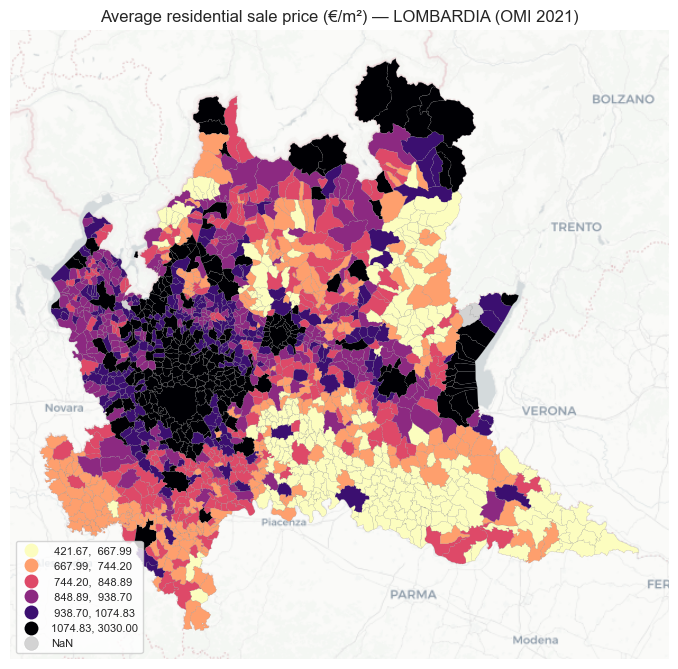

In [15]:
muni_omi = muni.merge(omi_muni, on="belfiore", how="left")
cov = muni_omi["price_m2"].notna().mean() * 100
print(f"OMI price join coverage: {cov:.1f}% of polygons")

choropleth(muni_omi, "price_m2",
           f"Average residential sale price (€/m²) — {REGION or 'Italy'} (OMI {OMI_YEAR})",
           cmap="magma_r")
plt.show()

## 9. Income vs. real-estate price

Combine the municipal income and price aggregates: how do they relate, and where is housing most
expensive relative to income?

1499 municipalities with both metrics | Pearson r = 0.45


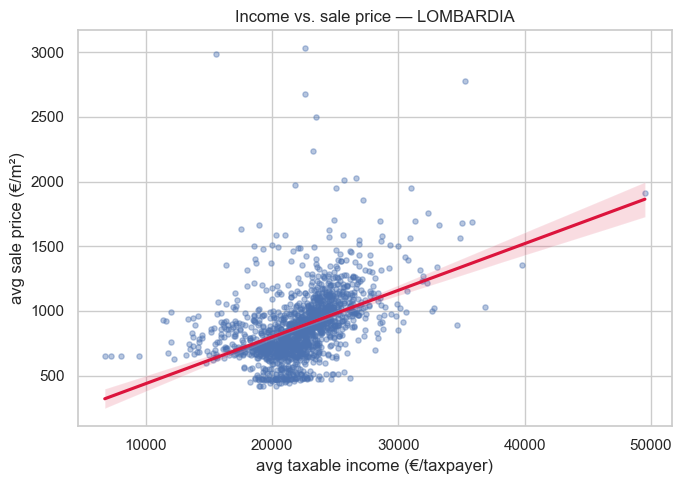

In [ ]:
combo = (red_view[["belfiore", COL_COMUNE, COL_PROV, "avg_income"]]
         .merge(omi_muni[["belfiore", "price_m2", "rent_m2", "n_quotes"]], on="belfiore")
         .dropna(subset=["avg_income", "price_m2"]))
combo = combo[(combo["avg_income"] > 0) & (combo["price_m2"] > 0)]
r = combo["avg_income"].corr(combo["price_m2"])
print(f"{len(combo)} municipalities with both metrics | Pearson r = {r:.2f}")

ax = sns.regplot(data=combo, x="avg_income", y="price_m2")
ax.set(title=f"Income vs. sale price — {REGION or 'Italy'}",
       xlabel="avg taxable income (€/taxpayer)", ylabel="avg sale price (€/m²)")
ax.figure.set_size_inches(7, 5); plt.tight_layout(); plt.show()